# Projet IA — Exploratory Data Analysis

## Introduction

Ce notebook a pour objectif d'analyser les données RH d'HumanForYou afin de comprendre et prédire l'attrition des employés. Les données proviennent de plusieurs sources fusionnées : données générales, enquêtes employés, enquêtes managers et horaires de présence.

**Plan du notebook :**
1. Importation des bibliothèques
2. Configuration de l'environnement
3. Chargement et fusion des données
4. Préparation des données (valeurs manquantes + suppression colonnes non informatives)
5. Feature engineering — Heures travaillées
6. Distribution de la variable cible — Attrition
7. Analyse univariée
8. Analyse bivariée — Variables vs Attrition (tests statistiques)
9. Analyse dédiée — Heures travaillées vs Attrition
10. Matrice de corrélation
11. Conclusion

---

## 1. Importation des bibliothèques

On importe les bibliothèques essentielles :
- **NumPy** et **Pandas** pour la manipulation des données
- **Matplotlib** et **Seaborn** pour la visualisation
- **SciPy** pour les tests statistiques (Mann-Whitney U, Chi²)
- **missingno** pour la visualisation des valeurs manquantes
- **warnings** et **os** pour la gestion de l'environnement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
import warnings
import os

## 2. Configuration de l'environnement

Configuration des paramètres d'affichage globaux pour rendre les visualisations et sorties plus lisibles.

In [2]:
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## 3. Chargement et fusion des données

Les données sont réparties dans plusieurs fichiers CSV. On les fusionne en un seul DataFrame `employee_data` via l'identifiant commun `EmployeeID`.

- `general_data.csv` — informations générales (âge, département, salaire, etc.)
- `employee_survey_data.csv` — enquête de satisfaction des employés
- `manager_survey_data.csv` — évaluations des managers
- `in_time.csv` / `out_time.csv` — horaires de présence (utilisés en section 5)

In [3]:
data_dir = 'data'

employee_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'employee_survey_data.csv'))
general_data    = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'general_data.csv'))
manager_survey  = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'manager_survey_data.csv'))
in_time         = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'in_time.csv'))
out_time        = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'out_time.csv'))

in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

# Fusion des données RH
employee_data = pd.merge(general_data, employee_survey, on='EmployeeID', how='left')
employee_data = pd.merge(employee_data, manager_survey, on='EmployeeID', how='left')

print(f'Shape du dataset fusionné : {employee_data.shape}')
employee_data.head()

Shape du dataset fusionné : (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3.00,4.00,2.00,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,3.00,2.00,4.00,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,2.00,2.00,1.00,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,4.00,4.00,3.00,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,4.00,1.00,3.00,3,3


## 4. Feature engineering — Heures travaillées

Les fichiers `in_time` et `out_time` contiennent les horaires d'arrivée et de départ de chaque employé pour chaque jour de l'année 2015.

On calcule ici, pour chaque employé :
- **`avg_hours_worked`** — durée de travail quotidienne moyenne (en heures)

**Traitement :**
- Conversion des colonnes de timestamps en objets `datetime`
- Calcul de la durée journalière pour chaque présence (NaN si absent ce jour-là)
- Moyenne par employé sur l'ensemble de l'année

Une fois la fusion effectuée, `EmployeeID` est supprimé et les listes de colonnes sont mises à jour.

> **Note :** Les jours d'absence sont exclus du calcul (non comptés comme 0h travaillée).

In [4]:
# Conversion des colonnes de dates
date_cols = [c for c in in_time.columns if c != 'EmployeeID']
in_time[date_cols]  = in_time[date_cols].apply(pd.to_datetime, errors='coerce')
out_time[date_cols] = out_time[date_cols].apply(pd.to_datetime, errors='coerce')

# Calcul de la durée quotidienne en heures (NaN si absent)
work_duration       = out_time[date_cols] - in_time[date_cols]
work_duration_hours = work_duration.apply(lambda col: col.dt.total_seconds() / 3600)

# Moyenne par employé sur l'année
avg_hours = work_duration_hours.mean(axis=1)
hours_df  = pd.DataFrame({'EmployeeID': in_time['EmployeeID'], 'avg_hours_worked': avg_hours})

# Fusion dans le dataset principal
employee_data = pd.merge(employee_data, hours_df, on='EmployeeID', how='left')

# Suppression de EmployeeID (identifiant sans pouvoir prédictif)
employee_data.drop(columns=['EmployeeID'], inplace=True)
print('✓ avg_hours_worked ajouté, EmployeeID supprimé.')

# Recalcul final des colonnes (avg_hours_worked inclus, EmployeeID exclu)
numerical_columns   = employee_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques finales ({len(numerical_columns)}) :')
print(numerical_columns)
print(f'\nVariables catégorielles finales ({len(categorical_columns)}) :')
print(categorical_columns)
print(f'\nShape finale : {employee_data.shape}')
employee_data[['avg_hours_worked']].describe()

✓ avg_hours_worked ajouté, EmployeeID supprimé.

Variables numériques finales (21) :
['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']

Variables catégorielles finales (8) :
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']

Shape finale : (4410, 29)


C:\Users\ethan\AppData\Local\Temp\ipykernel_59384\2391096606.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()


,avg_hours_worked
count,4410.00
mean,7.70
std,1.34
min,5.95
25%,6.67
50%,7.41
75%,8.37
max,11.03


## 5. Préparation des données

Cette étape regroupe tout le nettoyage **avant toute analyse**, pour éviter d'analyser des données bruitées.

### 5.1 Gestion des valeurs manquantes

**Stratégie d'imputation :**
- **Variables numériques** → remplacement par la **médiane** (robuste aux valeurs aberrantes)
- **Variables catégorielles** → remplacement par le **mode** (valeur la plus fréquente)

### 5.2 Suppression des colonnes non informatives

Colonnes présentant une valeur unique pour tous les employés — aucun pouvoir discriminant :
- **`EmployeeCount`** — toujours égal à 1
- **`Over18`** — toujours égal à `Y`
- **`StandardHours`** — toujours égal à 8

> **Note :** `EmployeeID` est un identifiant technique sans pouvoir prédictif. Il est exclu des analyses numériques mais conservé temporairement pour la fusion des horaires (section 5).

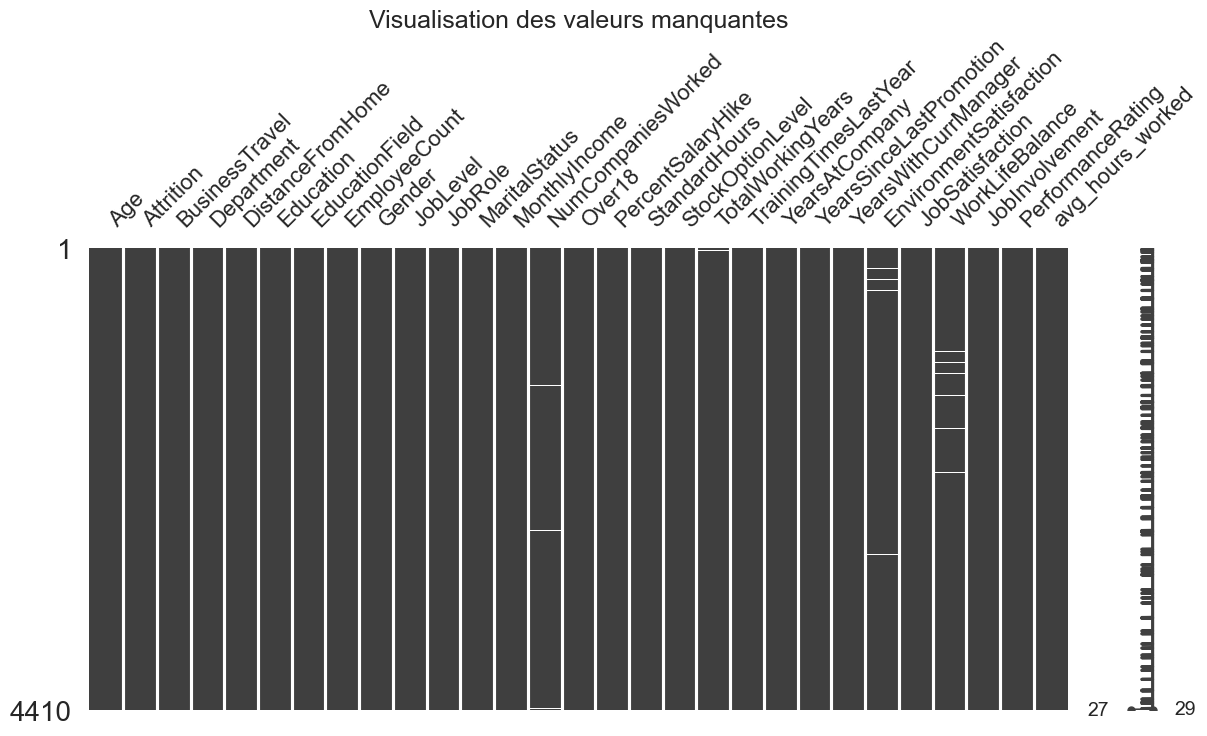

Valeurs manquantes après imputation :
→ Aucune

Colonnes supprimées (valeur unique) : ['EmployeeCount', 'Over18', 'StandardHours']
Shape après nettoyage : (4410, 26)

Variables numériques (19) : ['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']
Variables catégorielles (7) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


C:\Users\ethan\AppData\Local\Temp\ipykernel_59384\3648509162.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()
C:\Users\ethan\AppData\Local\Temp\ipykernel_59384\3648509162.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://

In [5]:
# --- 4.1 Valeurs manquantes ---

# Visualisation
msno.matrix(employee_data, figsize=(14, 6))
plt.title('Visualisation des valeurs manquantes')
plt.show()

# Imputation numérique → médiane
numerical_columns = employee_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
employee_data[numerical_columns] = employee_data[numerical_columns].fillna(
    employee_data[numerical_columns].median()
)

# Imputation catégorielle → mode
# Over18 : toutes les valeurs connues sont 'Y', on impute avec 'Y'
employee_data['Over18'] = employee_data['Over18'].fillna('Y')
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()
employee_data[categorical_columns] = employee_data[categorical_columns].fillna(
    employee_data[categorical_columns].mode().iloc[0]
)

# Vérification
missing = employee_data.isnull().sum()
remaining = missing[missing > 0]
print('Valeurs manquantes après imputation :')
print('→ Aucune' if remaining.empty else remaining)

# --- 4.2 Suppression des colonnes non informatives ---
# EmployeeID conservé temporairement pour la fusion des horaires (section 5)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
employee_data.drop(columns=cols_to_drop, inplace=True)
print(f'\nColonnes supprimées (valeur unique) : {cols_to_drop}')
print(f'Shape après nettoyage : {employee_data.shape}')

# Recalcul des colonnes — EmployeeID exclu car identifiant technique
numerical_columns   = [c for c in employee_data.select_dtypes(include=['float64', 'int64']).columns
                        if c != 'EmployeeID']
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques ({len(numerical_columns)}) : {numerical_columns}')
print(f'Variables catégorielles ({len(categorical_columns)}) : {categorical_columns}')

## 6. Distribution de la variable cible — Attrition

Avant toute analyse des variables, il est essentiel de visualiser la distribution de la variable cible `Attrition`.

Un fort déséquilibre entre les classes peut biaiser les modèles vers la classe majoritaire. Dans ce cas, des techniques de rééchantillonnage (SMOTE, undersampling) ou l'ajustement des poids de classe seront nécessaires lors de la modélisation.

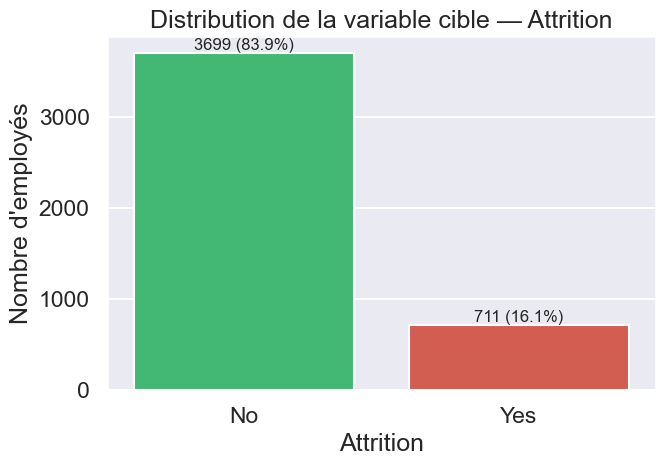

Classe No  : 3699 employés (83.9%)
Classe Yes : 711 employés (16.1%)

→ Déséquilibre détecté : ratio 5.2:1
→ Une technique de rééchantillonnage (SMOTE) sera appliquée lors de la modélisation.


In [6]:
attrition_counts = employee_data['Attrition'].value_counts()
attrition_pct    = employee_data['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=employee_data, palette=['#2ecc71', '#e74c3c'])
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(employee_data)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )
plt.title('Distribution de la variable cible — Attrition')
plt.xlabel('Attrition')
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

print(f'Classe No  : {attrition_counts["No"]} employés ({attrition_pct["No"]:.1f}%)')
print(f'Classe Yes : {attrition_counts["Yes"]} employés ({attrition_pct["Yes"]:.1f}%)')
print(f'\n→ Déséquilibre détecté : ratio {attrition_counts["No"]/attrition_counts["Yes"]:.1f}:1')
print('→ Une technique de rééchantillonnage (SMOTE) sera appliquée lors de la modélisation.')

## 7. Analyse univariée des variables

Cette étape consiste à examiner chaque variable individuellement pour comprendre sa distribution.

- **Variables numériques** : si la variable prend moins de 10 valeurs distinctes → `countplot` (variable ordinale/discrète) ; sinon → histogramme + courbe de densité (KDE).
- **Variables catégorielles** : fréquences par modalité avec un `countplot`.

Cette exploration permet de détecter des déséquilibres, des distributions atypiques et des variables peu discriminantes.

> **Point d'attention :** `PerformanceRating` ne prend que les valeurs 3 et 4 dans ce dataset — variable a priori peu discriminante.

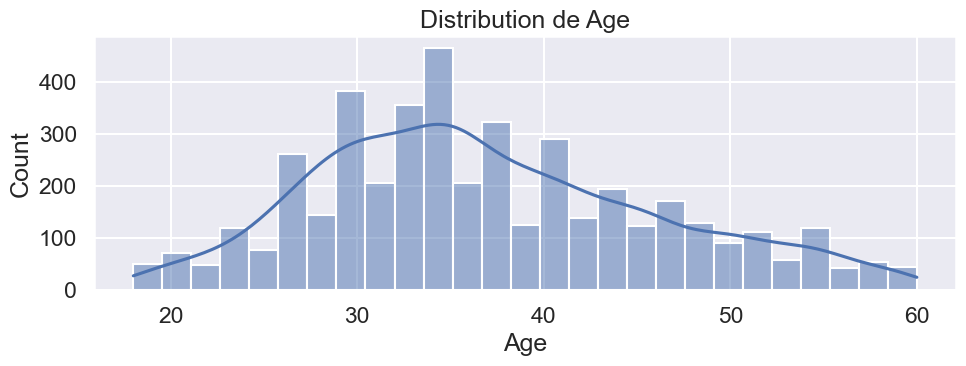

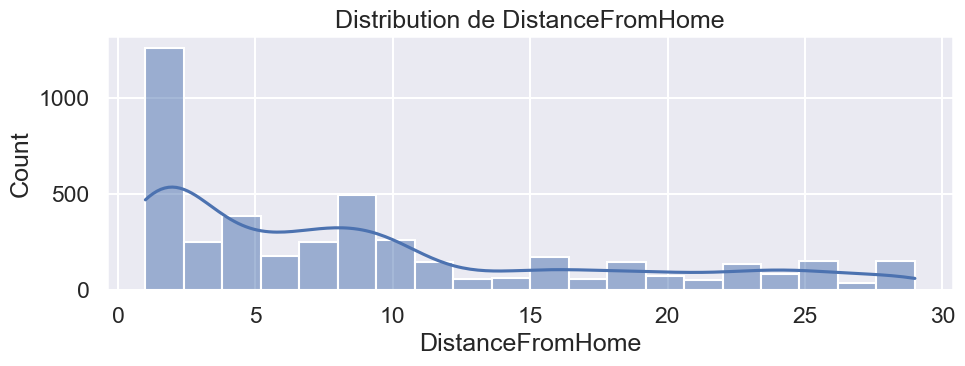

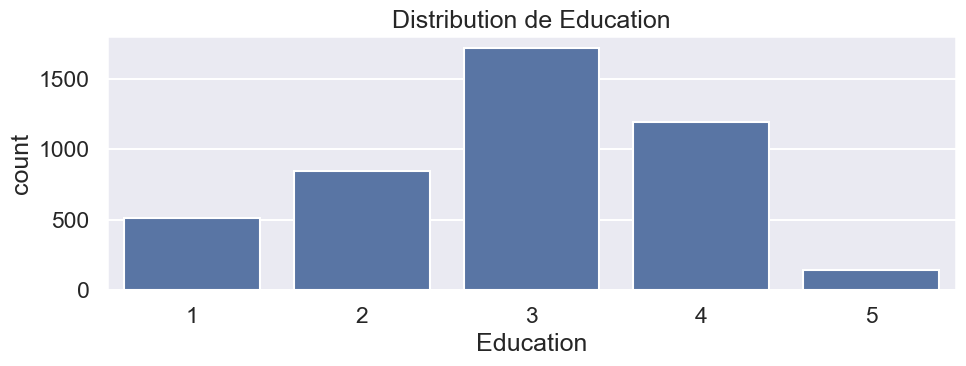

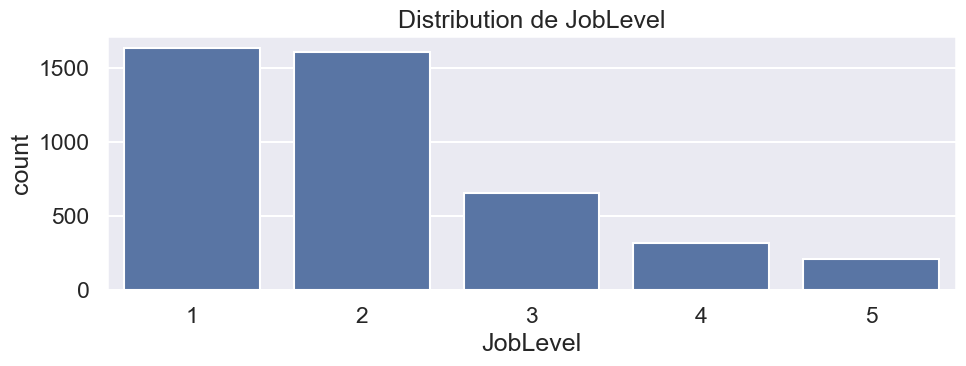

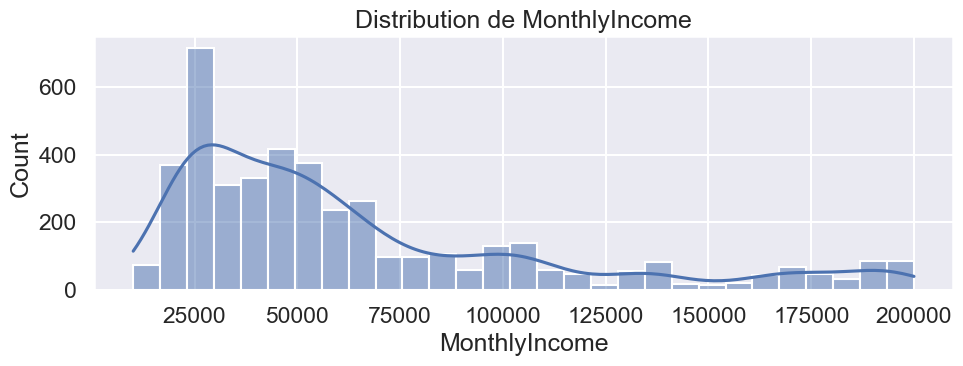

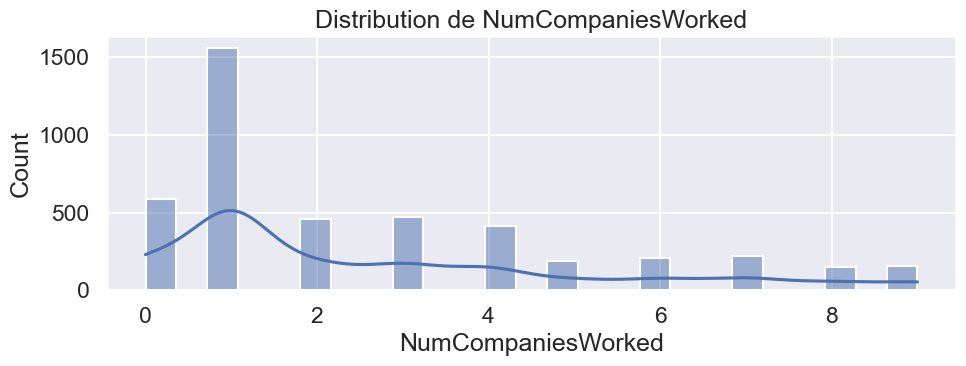

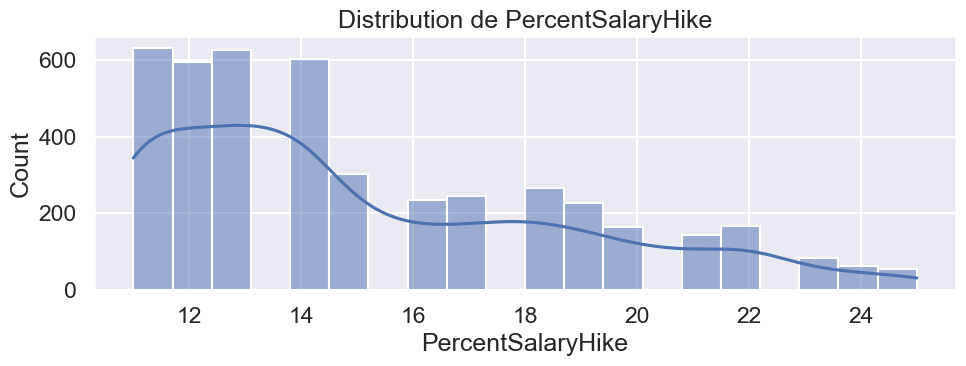

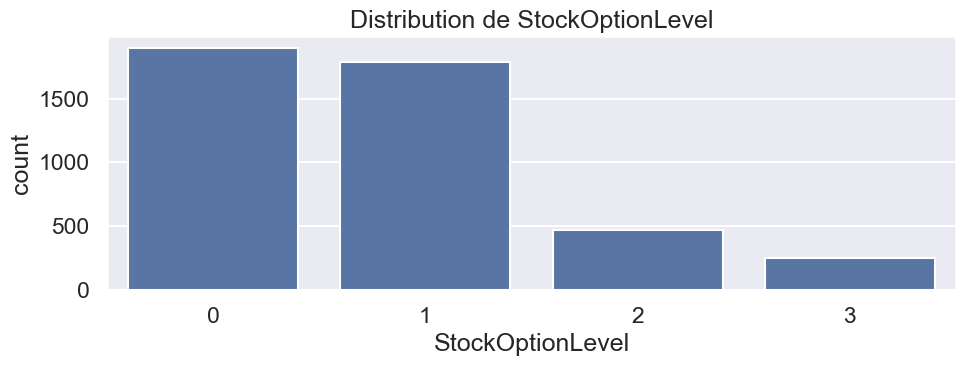

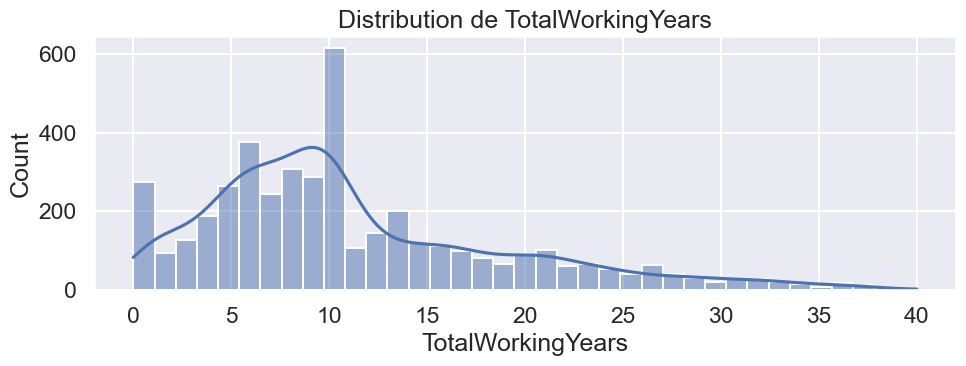

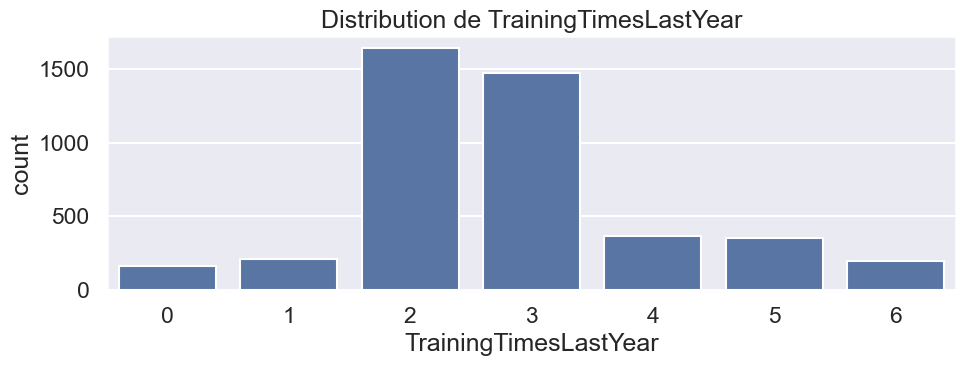

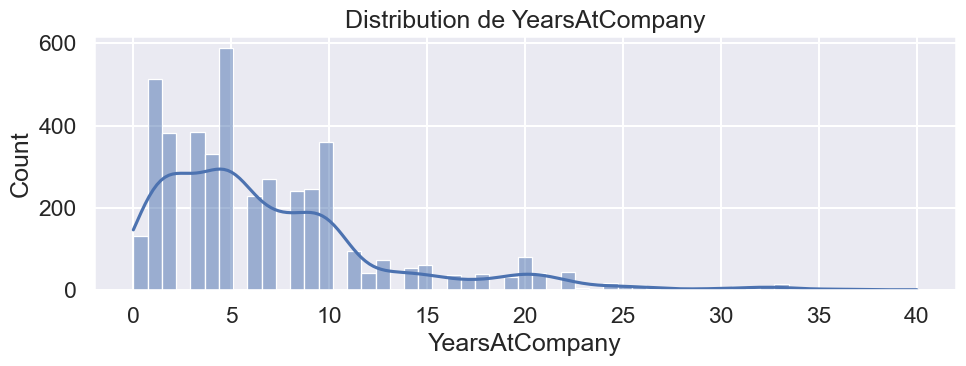

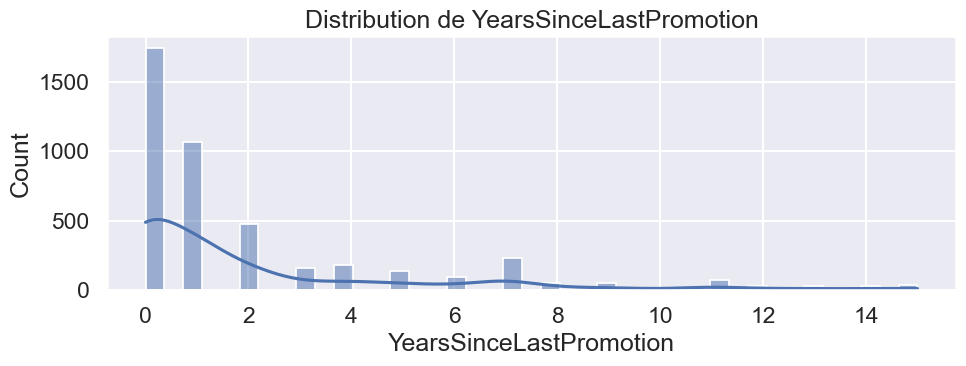

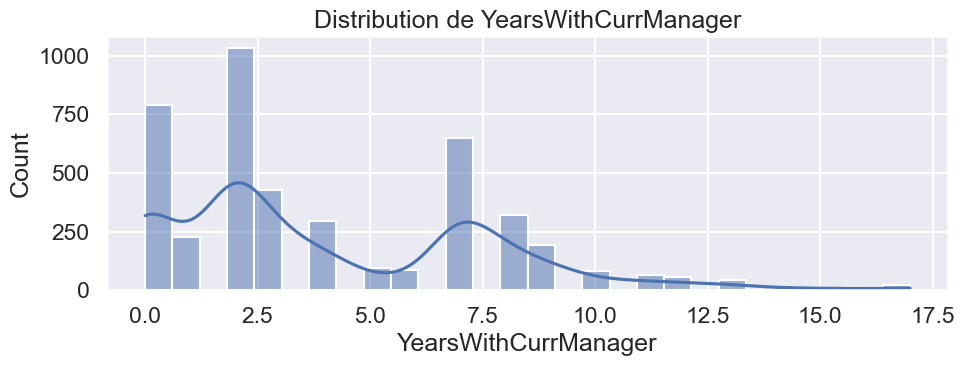

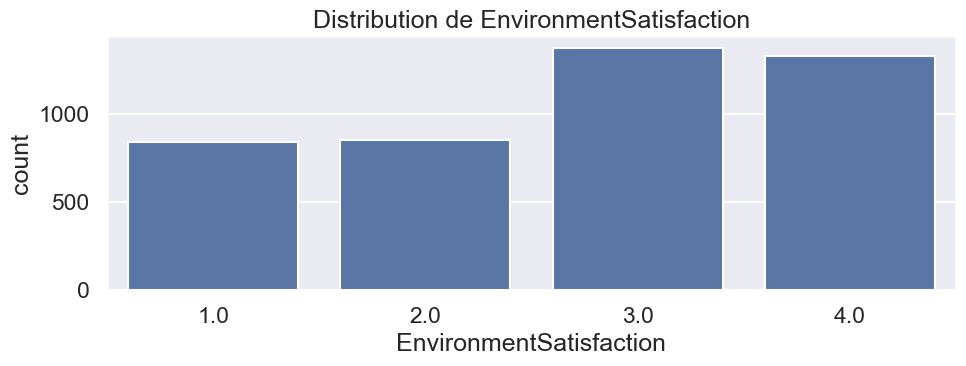

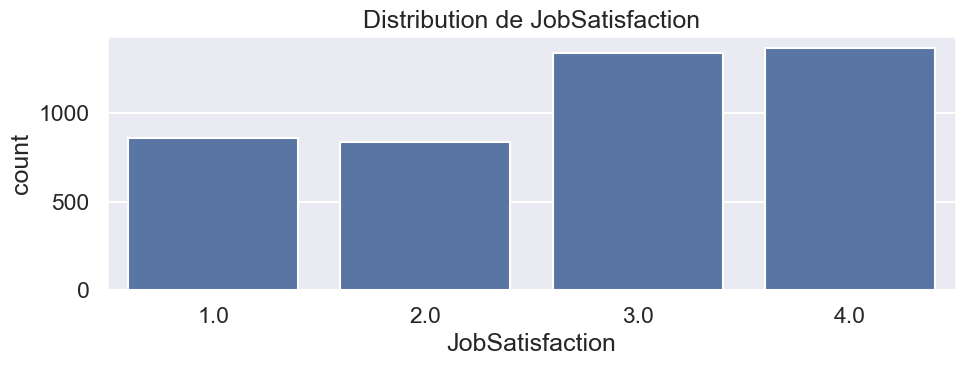

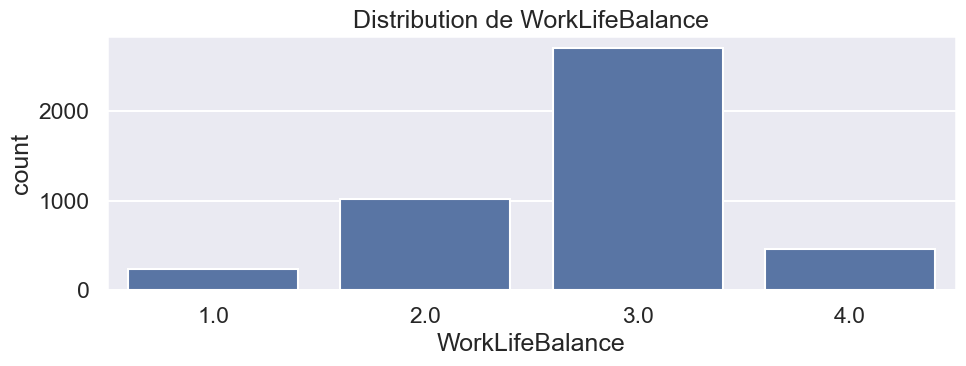

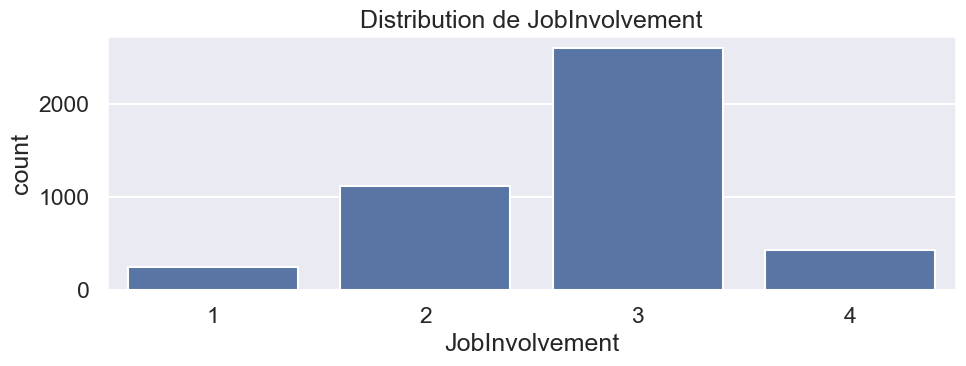

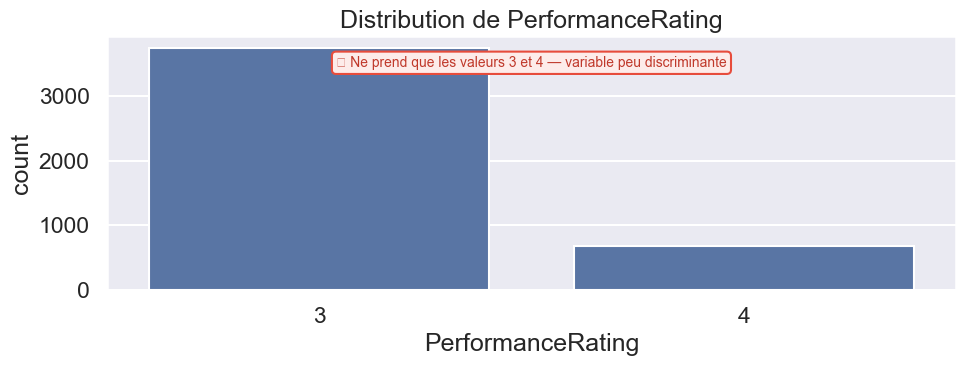

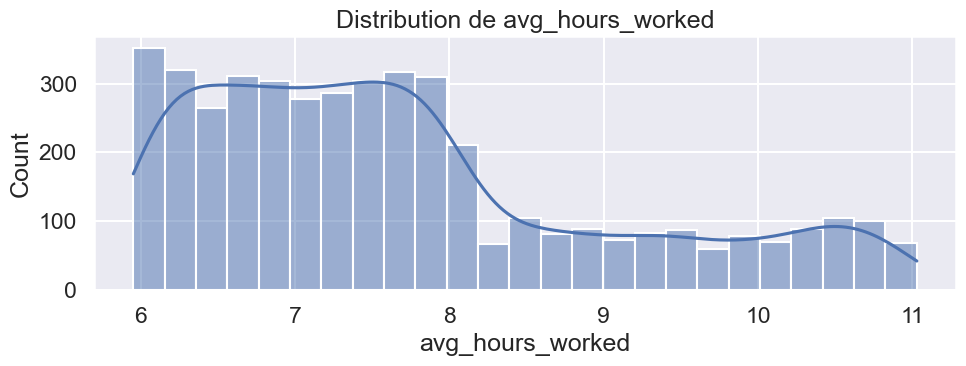

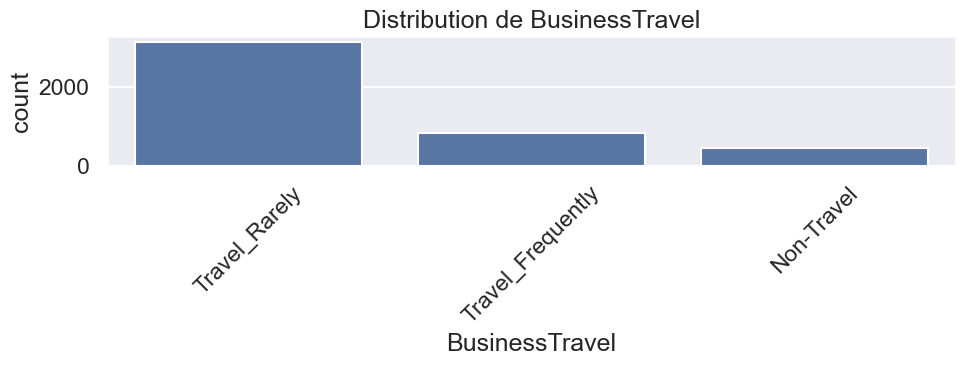

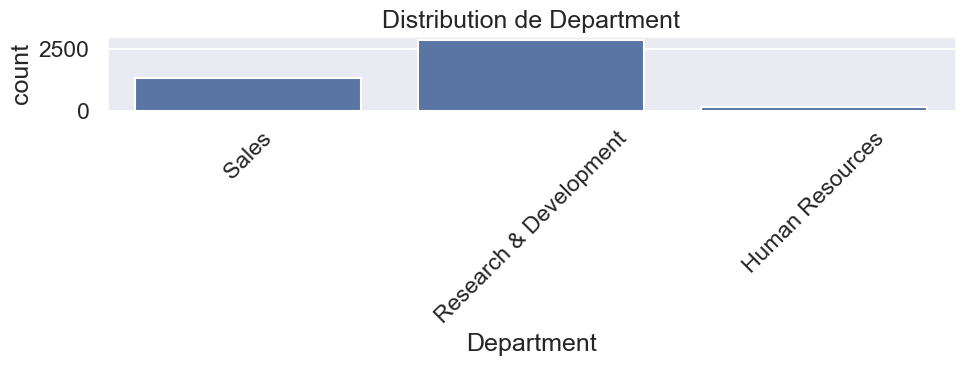

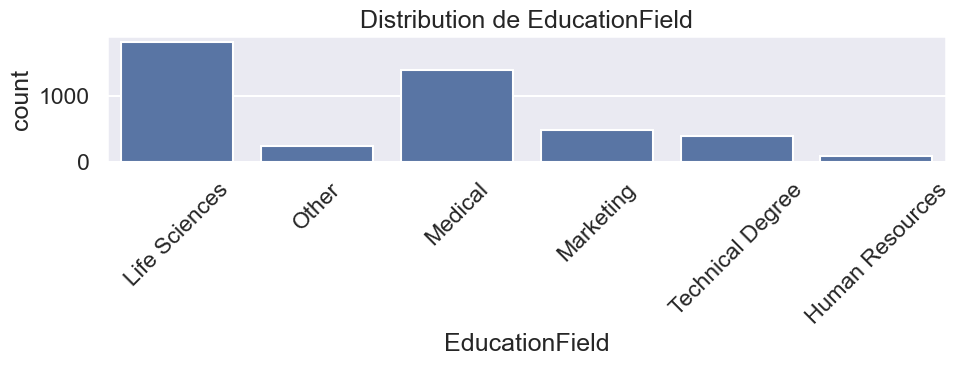

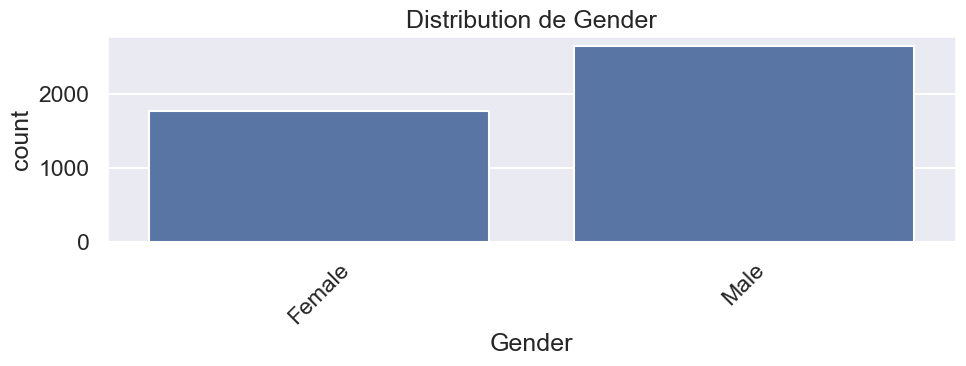

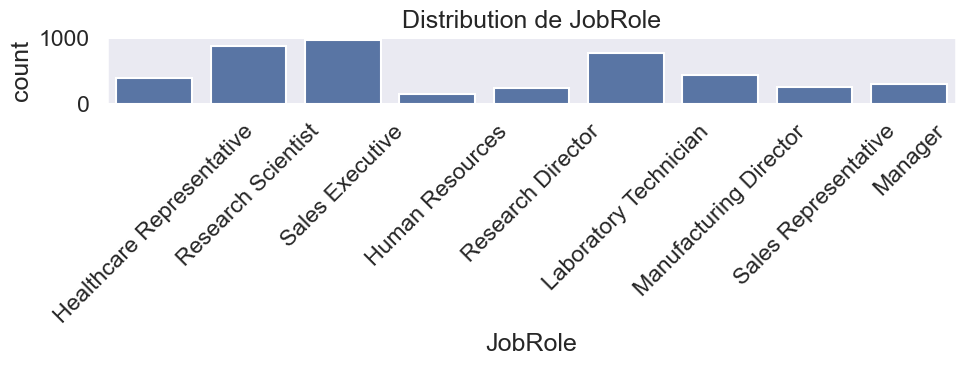

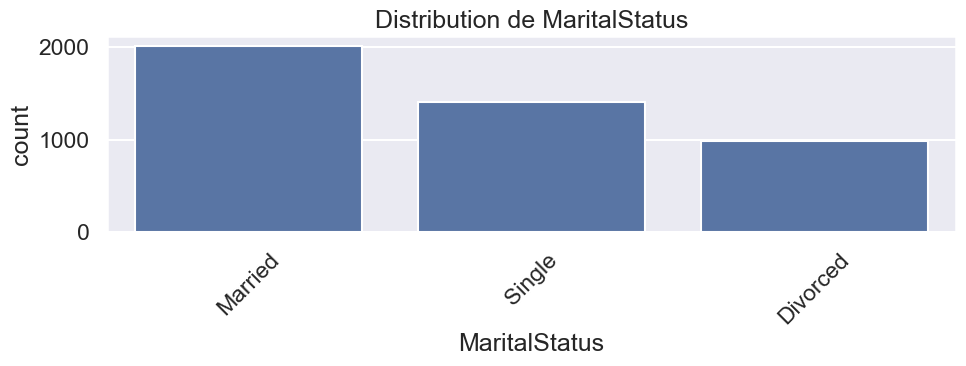

In [7]:
# --- Variables numériques ---
for column in numerical_columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    if employee_data[column].nunique() < 10:
        sns.countplot(x=employee_data[column], ax=ax)
    else:
        sns.histplot(employee_data[column], kde=True, ax=ax)
    ax.set_title(f'Distribution de {column}')
    # Alerte pour PerformanceRating (seulement valeurs 3 et 4)
    if column == 'PerformanceRating':
        ax.text(0.5, 0.88,
                '⚠ Ne prend que les valeurs 3 et 4 — variable peu discriminante',
                transform=ax.transAxes, ha='center', fontsize=10, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))
    plt.tight_layout()
    plt.show()

# --- Variables catégorielles (hors Attrition) ---
for column in categorical_columns:
    if column == 'Attrition':
        continue
    plt.figure(figsize=(10, 4))
    sns.countplot(x=employee_data[column])
    plt.title(f'Distribution de {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Analyse bivariée — Variables vs Attrition

L'analyse bivariée consiste à croiser chaque variable avec la variable cible `Attrition` pour identifier les facteurs les plus discriminants.

- **Variables numériques** : comparaison des distributions via des `boxplots`, validée par un **test de Mann-Whitney U** (test non paramétrique adapté aux distributions non normales).
- **Variables catégorielles** : taux d'attrition par modalité, validé par un **test du Chi²** (indépendance entre la variable et Attrition).

**Lecture :** un p-value < 0.05 indique que la différence observée est statistiquement significative.

Cette étape est centrale pour répondre à la question métier : *quels sont les facteurs ayant le plus d'influence sur le départ des employés ?*

VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)


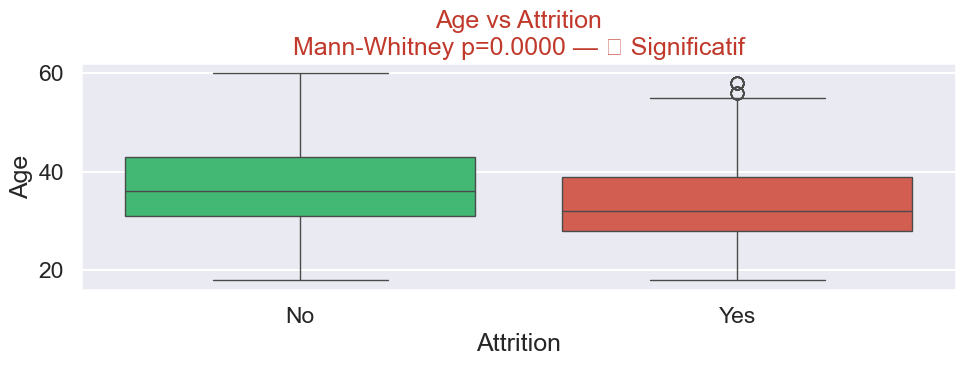

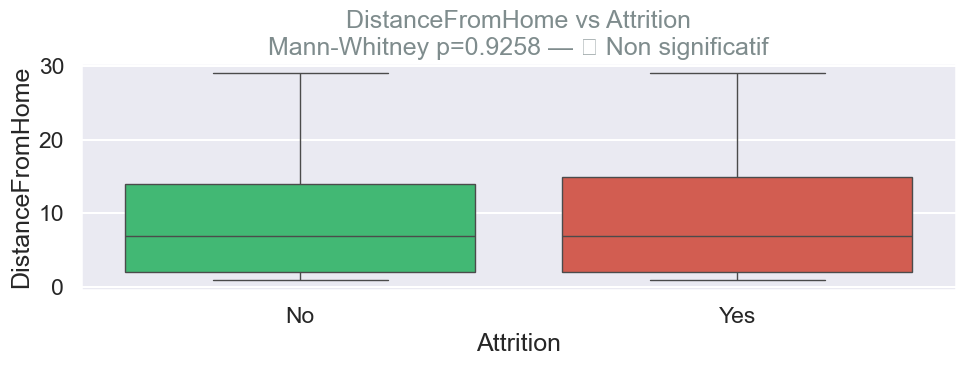

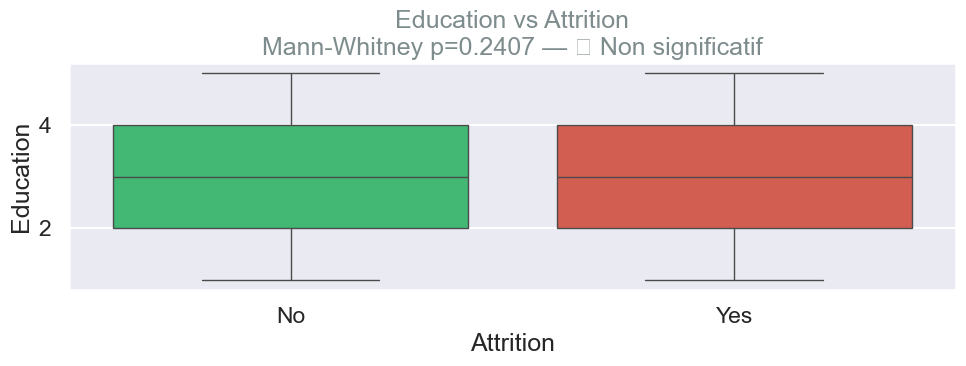

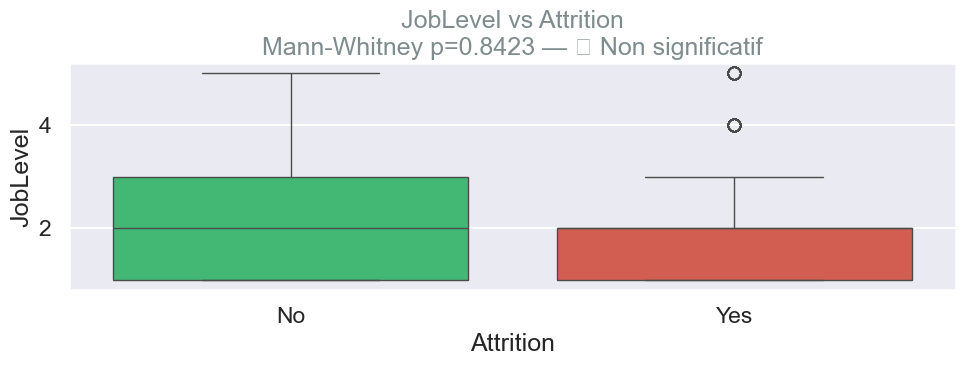

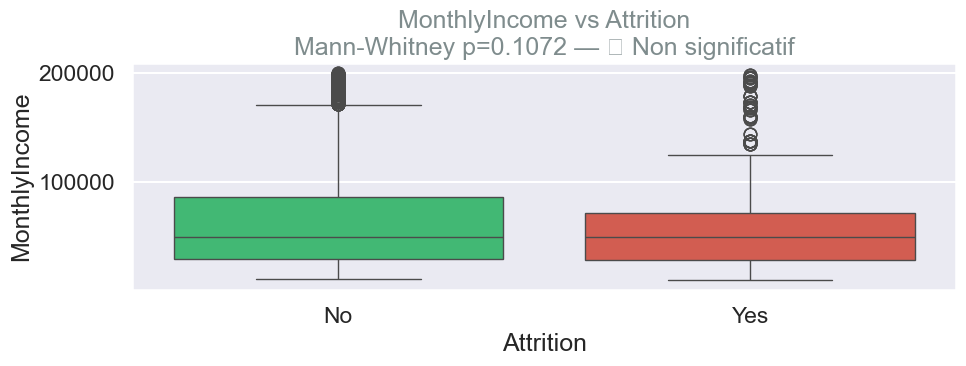

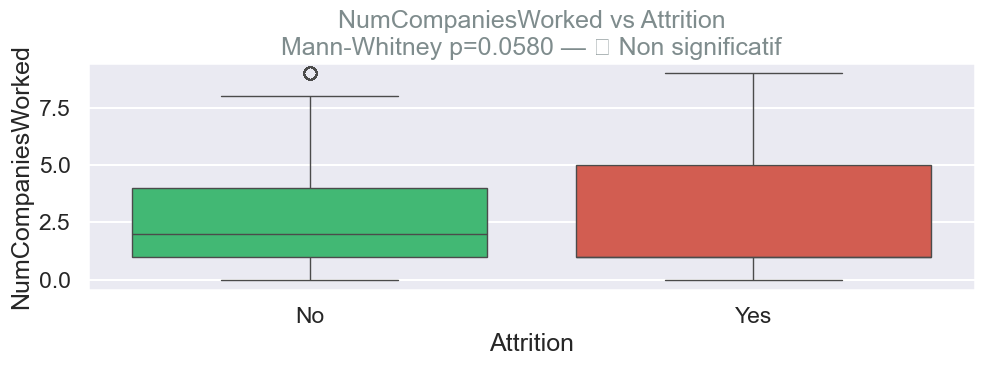

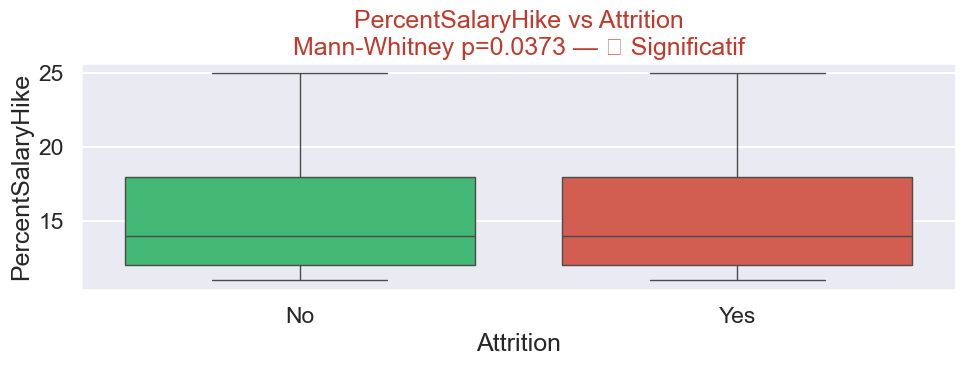

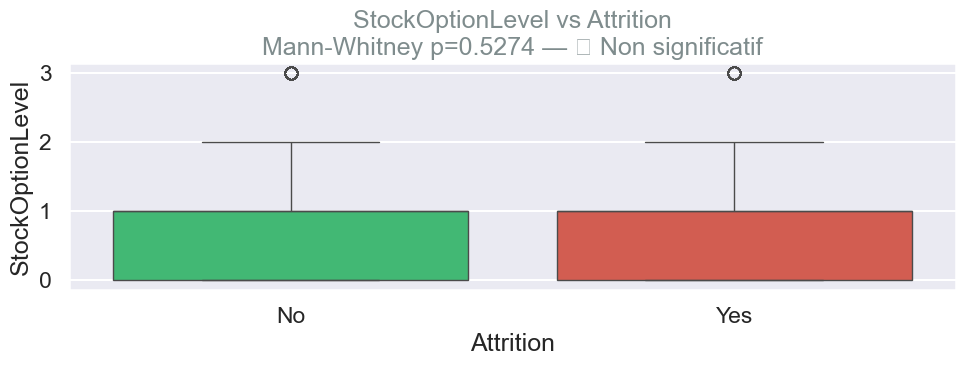

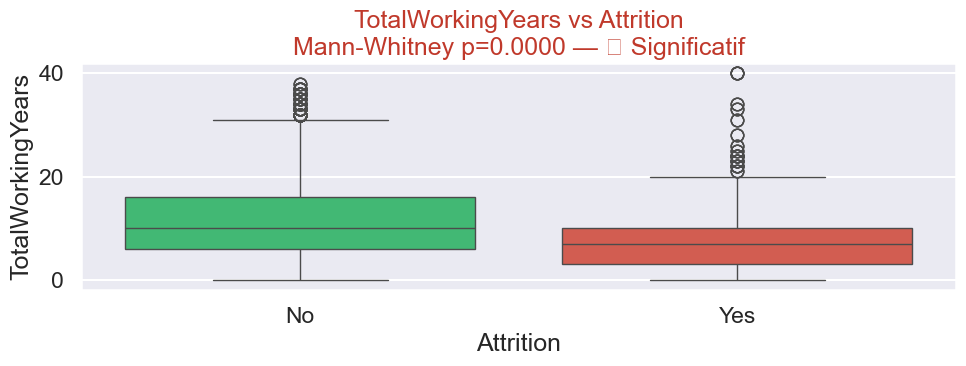

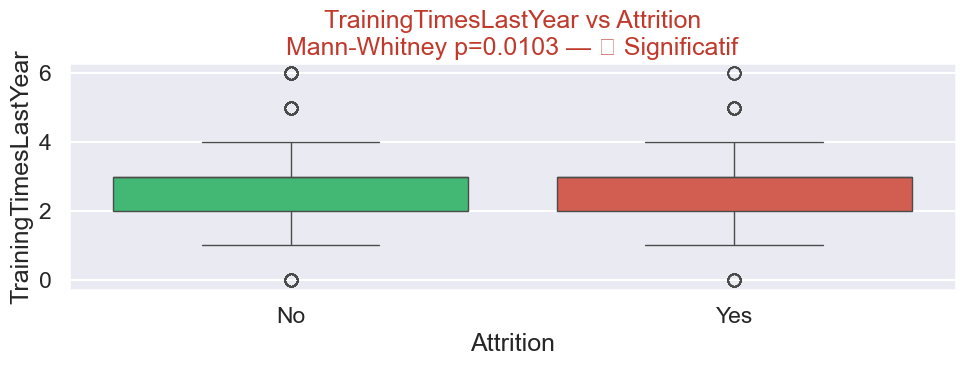

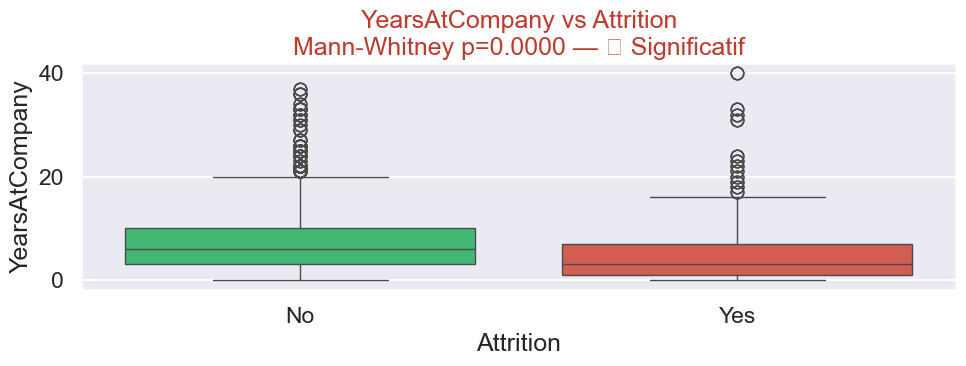

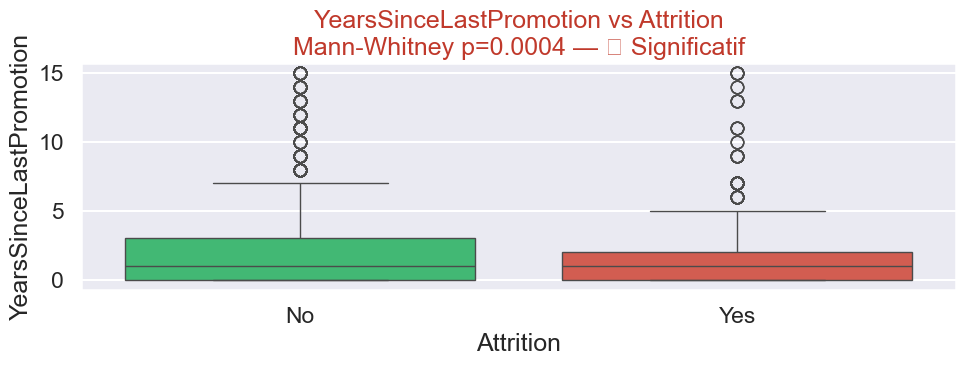

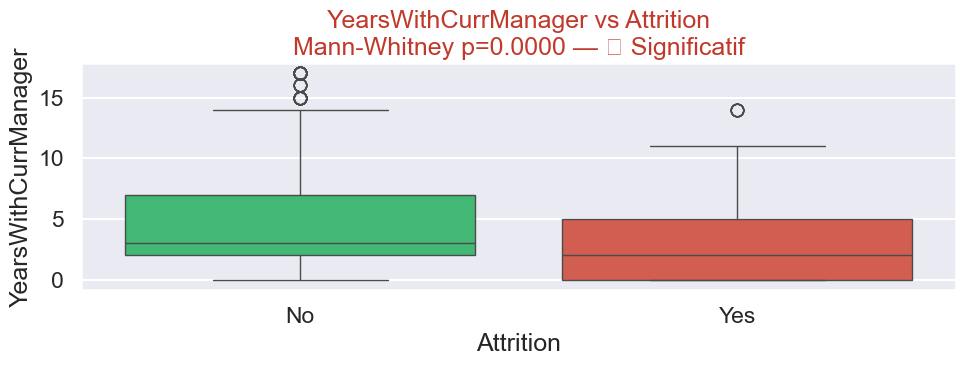

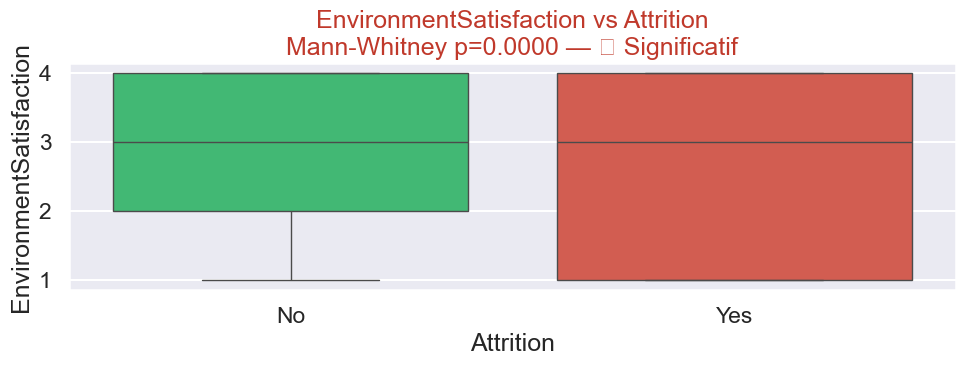

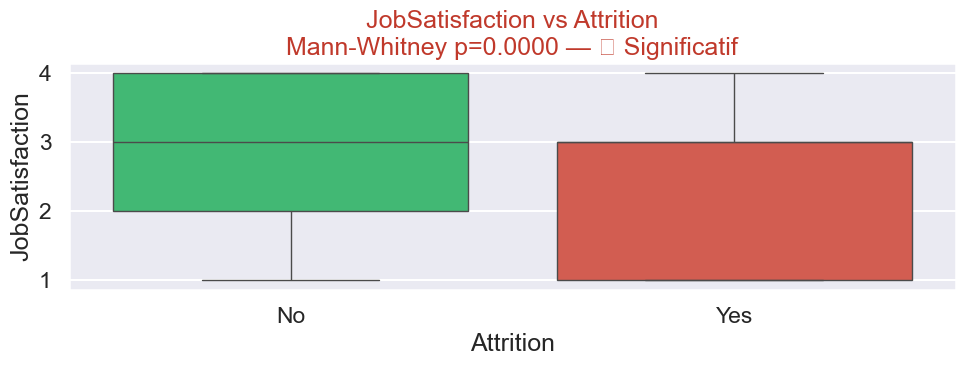

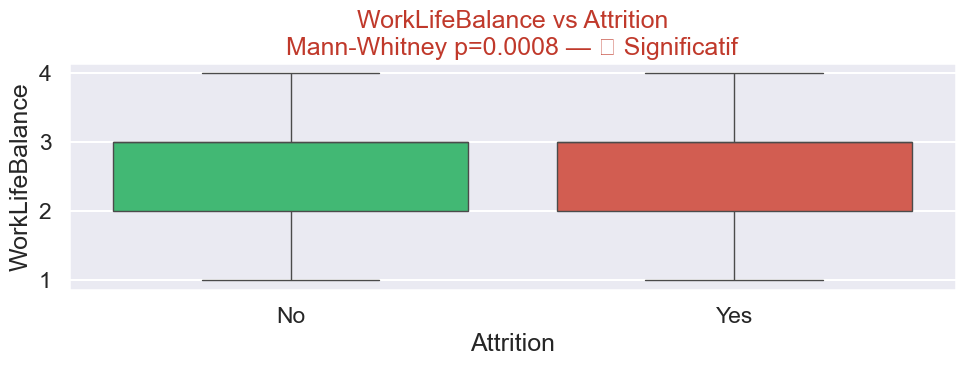

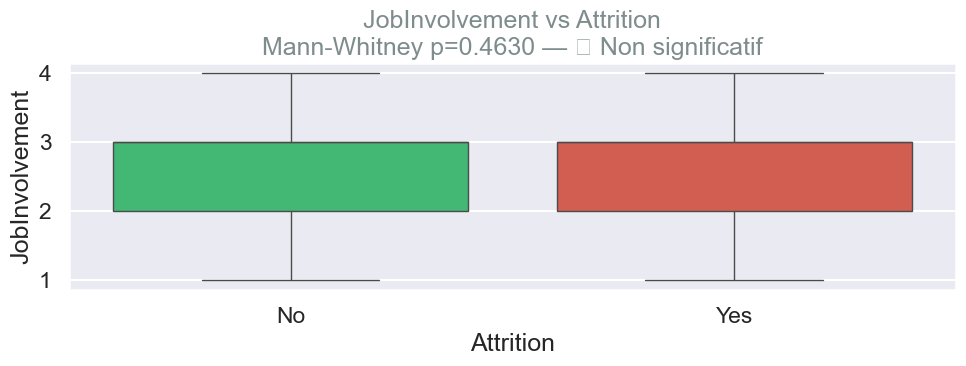

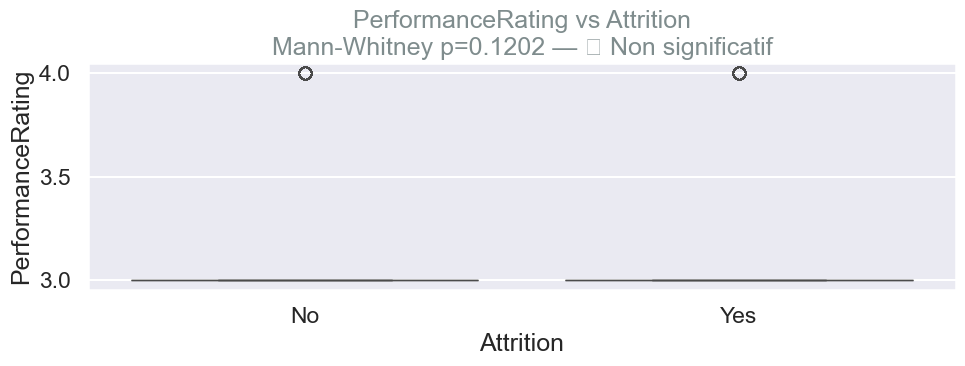

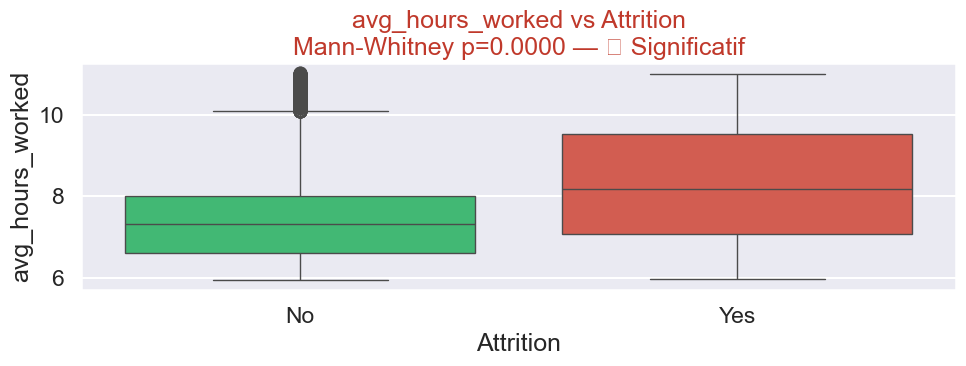


Récapitulatif Mann-Whitney U (trié par p-value) :
               Variable  p-value Significatif (p<0.05)
                    Age     0.00                     ✓
EnvironmentSatisfaction     0.00                     ✓
         YearsAtCompany     0.00                     ✓
        JobSatisfaction     0.00                     ✓
   YearsWithCurrManager     0.00                     ✓
      TotalWorkingYears     0.00                     ✓
       avg_hours_worked     0.00                     ✓
YearsSinceLastPromotion     0.00                     ✓
        WorkLifeBalance     0.00                     ✓
  TrainingTimesLastYear     0.01                     ✓
      PercentSalaryHike     0.04                     ✓
     NumCompaniesWorked     0.06                     ✗
          MonthlyIncome     0.11                     ✗
      PerformanceRating     0.12                     ✗
              Education     0.24                     ✗
         JobInvolvement     0.46                     ✗
       StockOp

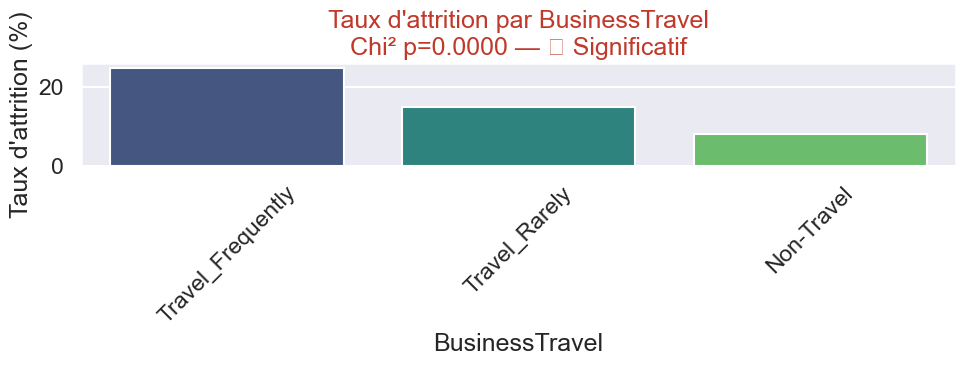

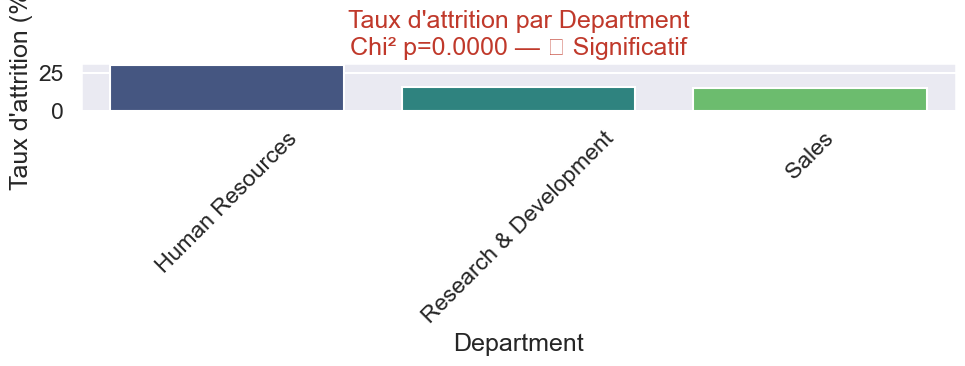

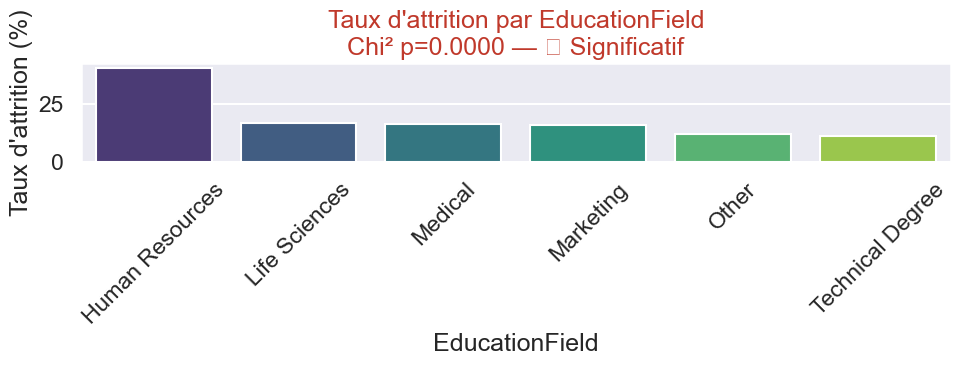

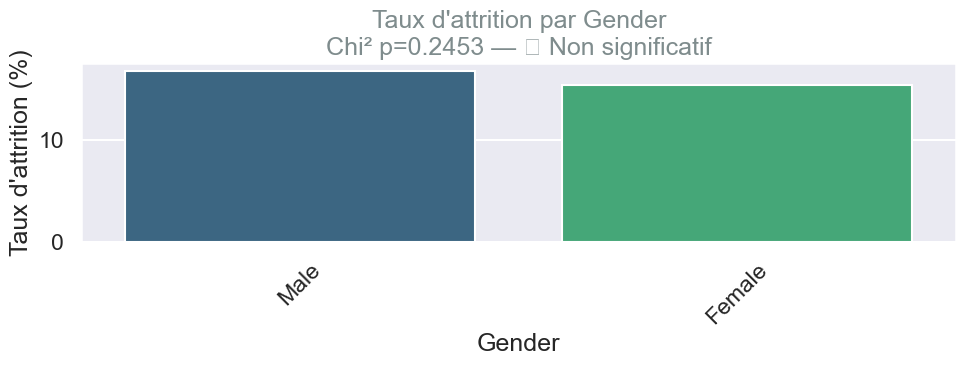

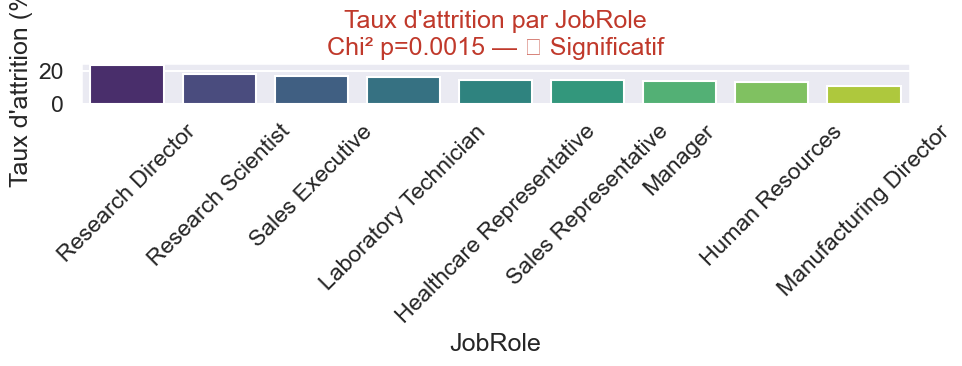

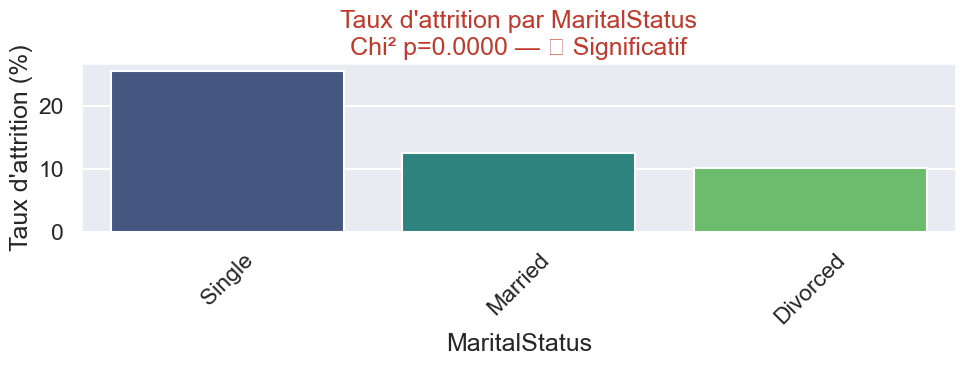


Récapitulatif Chi² (trié par p-value) :
      Variable  p-value Significatif (p<0.05)
BusinessTravel     0.00                     ✓
    Department     0.00                     ✓
EducationField     0.00                     ✓
 MaritalStatus     0.00                     ✓
       JobRole     0.00                     ✓
        Gender     0.25                     ✗


In [8]:
attrition_yes = employee_data[employee_data['Attrition'] == 'Yes']
attrition_no  = employee_data[employee_data['Attrition'] == 'No']

# VARIABLES NUMÉRIQUES vs ATTRITION — Boxplot + Mann-Whitney U
print('VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)')

results_num = []
for column in numerical_columns:
    stat, p_val = stats.mannwhitneyu(
        attrition_yes[column].dropna(),
        attrition_no[column].dropna(),
        alternative='two-sided'
    )
    significance = '✓ Significatif' if p_val < 0.05 else '✗ Non significatif'
    color_title  = '#c0392b' if p_val < 0.05 else '#7f8c8d'

    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Attrition', y=column, data=employee_data,
                palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{column} vs Attrition\nMann-Whitney p={p_val:.4f} — {significance}',
              color=color_title)
    plt.tight_layout()
    plt.show()

    results_num.append({
        'Variable': column,
        'p-value': round(p_val, 4),
        'Significatif (p<0.05)': '✓' if p_val < 0.05 else '✗'
    })

df_results_num = pd.DataFrame(results_num).sort_values('p-value')
print('\nRécapitulatif Mann-Whitney U (trié par p-value) :')
print(df_results_num.to_string(index=False))

# VARIABLES CATÉGORIELLES vs ATTRITION — Taux d'attrition + Chi²
print('VARIABLES CATÉGORIELLES vs ATTRITION (Chi²)')

results_cat = []
for column in categorical_columns:
    if column == 'Attrition':
        continue

    attrition_rate = employee_data.groupby(column)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    attrition_rate.columns = [column, "Taux d'attrition (%)"]
    attrition_rate = attrition_rate.sort_values("Taux d'attrition (%)", ascending=False)

    contingency = pd.crosstab(employee_data[column], employee_data['Attrition'])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency)
    significance = '✓ Significatif' if p_val < 0.05 else '✗ Non significatif'
    color_title  = '#c0392b' if p_val < 0.05 else '#7f8c8d'

    plt.figure(figsize=(10, 4))
    sns.barplot(x=column, y="Taux d'attrition (%)", data=attrition_rate, palette='viridis')
    plt.title(f"Taux d'attrition par {column}\nChi² p={p_val:.4f} — {significance}",
              color=color_title)
    plt.xticks(rotation=45)
    plt.ylabel("Taux d'attrition (%)")
    plt.tight_layout()
    plt.show()

    results_cat.append({
        'Variable': column,
        'p-value': round(p_val, 4),
        'Significatif (p<0.05)': '✓' if p_val < 0.05 else '✗'
    })

df_results_cat = pd.DataFrame(results_cat).sort_values('p-value')
print('\nRécapitulatif Chi² (trié par p-value) :')
print(df_results_cat.to_string(index=False))

## 9. Analyse dédiée — Heures travaillées vs Attrition

La variable `avg_hours_worked`, issue du feature engineering sur les fichiers de badgeage, mérite une analyse visuelle approfondie.

On cherche à valider l'hypothèse suivante : **les employés qui travaillent davantage sont-ils plus susceptibles de quitter l'entreprise ?**

On combine un boxplot (comparaison des médianes) et un graphe de densité KDE (visualisation complète des distributions par groupe).

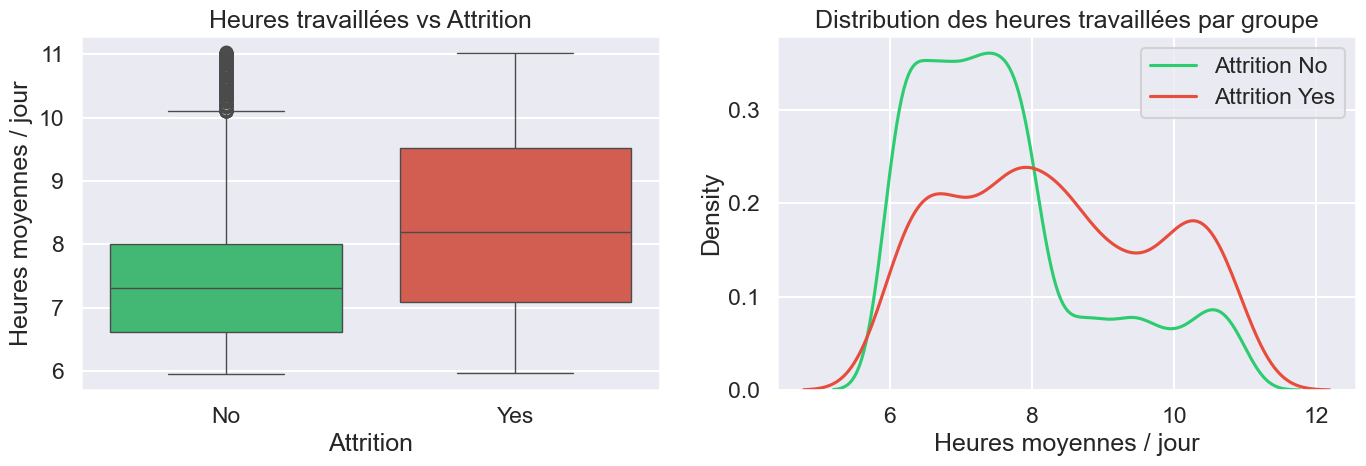

Statistiques heures travaillées par groupe :
            count  mean  std  min  25%  50%  75%   max
Attrition                                             
No        3699.00  7.58 1.28 5.95 6.61 7.31 8.00 11.03
Yes        711.00  8.32 1.46 5.96 7.09 8.19 9.53 11.02


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='Attrition', y='avg_hours_worked', data=employee_data,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Heures travaillées vs Attrition')
axes[0].set_ylabel('Heures moyennes / jour')

# Distribution KDE par groupe
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = employee_data[employee_data['Attrition'] == label]['avg_hours_worked']
    sns.kdeplot(subset, label=f'Attrition {label}', color=color, ax=axes[1])
axes[1].set_title('Distribution des heures travaillées par groupe')
axes[1].set_xlabel('Heures moyennes / jour')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Statistiques heures travaillées par groupe :')
print(employee_data.groupby('Attrition')['avg_hours_worked'].describe().round(2))

## 10. Matrice de corrélation

La heatmap de corrélation permet de visualiser les relations linéaires entre toutes les variables numériques.

Elle permet d'identifier :
- Les variables **fortement corrélées entre elles** (risque de multicolinéarité)
- Les variables **les plus corrélées à `Attrition`** (après encodage binaire : `Yes` → 1, `No` → 0)

> **Rappel :** la corrélation mesure uniquement les relations **linéaires**. Une corrélation faible ne signifie pas absence de relation non linéaire.

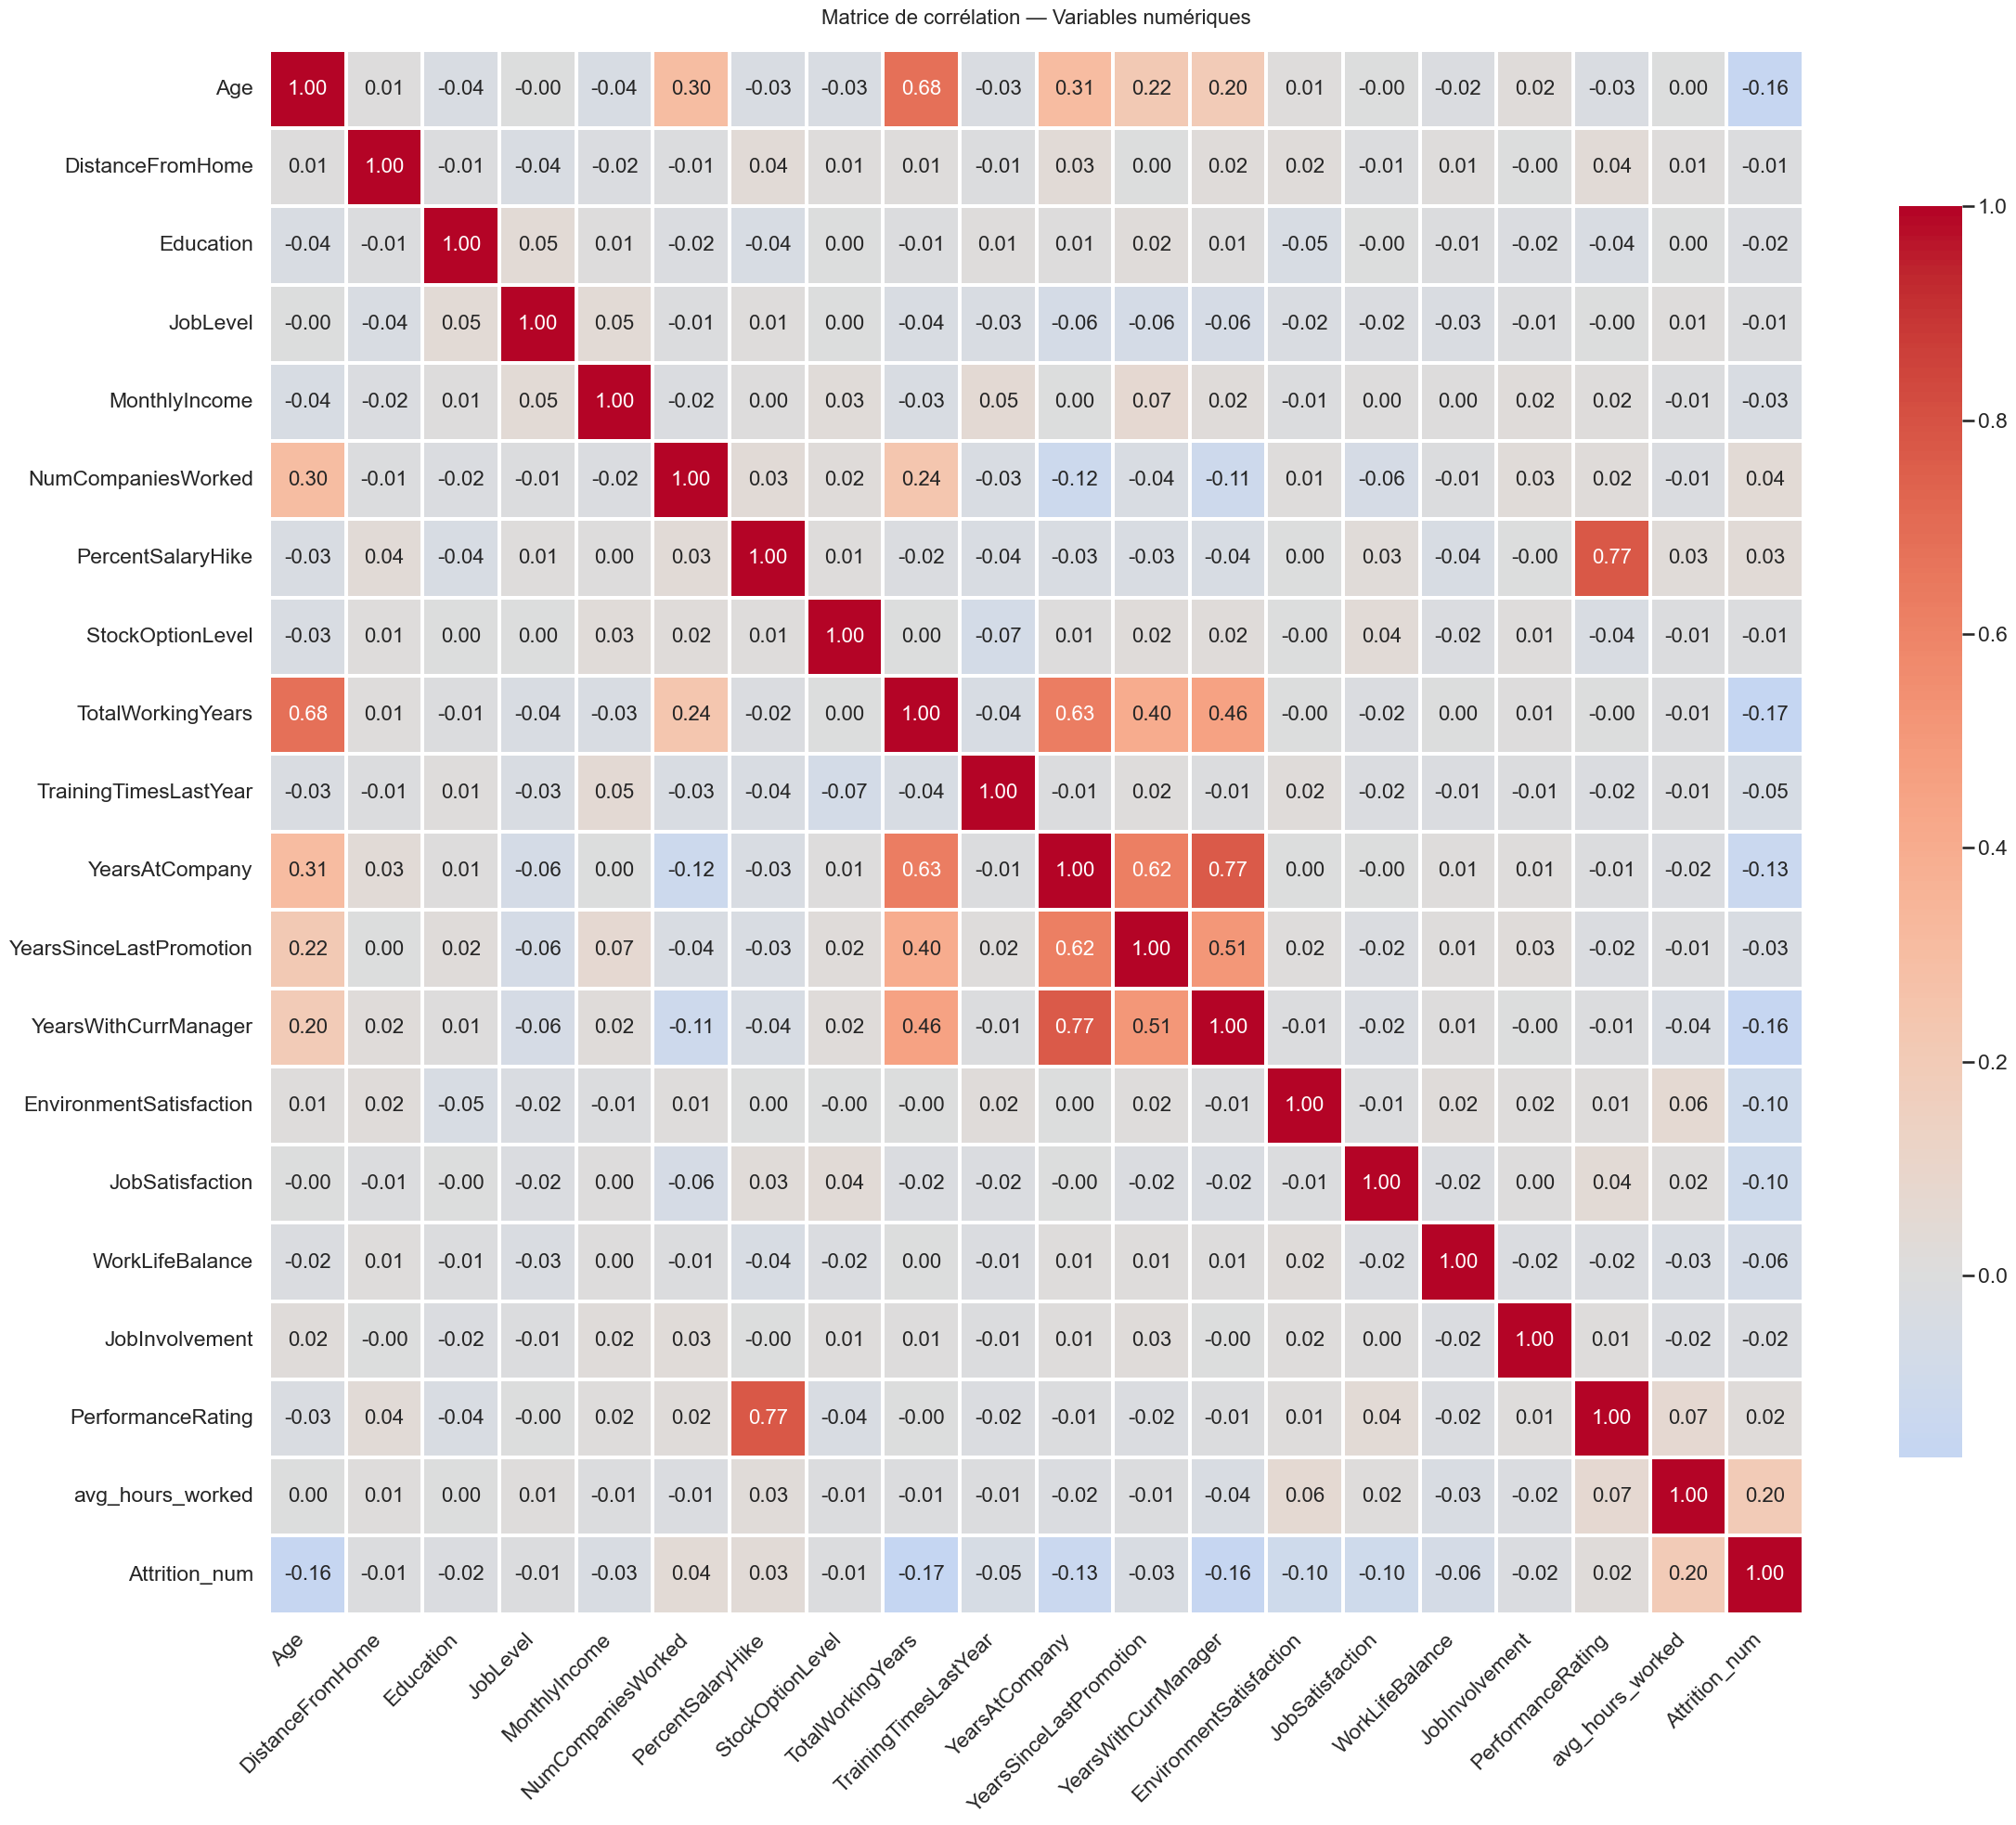

Corrélations avec Attrition (triées par valeur absolue) :
avg_hours_worked           0.20
TotalWorkingYears         -0.17
Age                       -0.16
YearsWithCurrManager      -0.16
YearsAtCompany            -0.13
JobSatisfaction           -0.10
EnvironmentSatisfaction   -0.10
WorkLifeBalance           -0.06
TrainingTimesLastYear     -0.05
NumCompaniesWorked         0.04
YearsSinceLastPromotion   -0.03
PercentSalaryHike          0.03
MonthlyIncome             -0.03
PerformanceRating          0.02
JobInvolvement            -0.02
Education                 -0.02
JobLevel                  -0.01
DistanceFromHome          -0.01
StockOptionLevel          -0.01
Name: Attrition_num, dtype: float64


In [10]:
corr_data = employee_data.copy()
corr_data['Attrition_num'] = corr_data['Attrition'].map({'Yes': 1, 'No': 0})

corr_cols   = [c for c in numerical_columns + ['Attrition_num'] if c in corr_data.columns]
corr_matrix = corr_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=1.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 16}
)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Corrélations avec Attrition (triées par valeur absolue) :')
print(corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False))

## 11. Conclusion de l'analyse exploratoire

L'analyse exploratoire a permis d'identifier les principaux facteurs associés à l'attrition des employés chez HumanForYou. Les tests statistiques (Mann-Whitney U et Chi²) confirment la significativité de la majorité des relations observées.

---

### Facteurs numériques significatifs

- **Charge de travail élevée** (`avg_hours_worked`) : les employés qui travaillent le plus d'heures sont proportionnellement plus nombreux à quitter l'entreprise — lien entre surcharge et désengagement.
- **Profil junior** (`TotalWorkingYears`, `Age`) : les employés jeunes avec peu d'ancienneté globale sont plus susceptibles de partir — mobilité professionnelle en début de carrière.
- **Relation avec le manager** (`YearsWithCurrManager`) : une longue collaboration avec le manager actuel est associée à une plus grande fidélité — la stabilité managériale est un facteur de rétention.
- **Satisfaction au travail** (`JobSatisfaction`, `EnvironmentSatisfaction`) : les employés insatisfaits de leur poste ou de leur environnement partent davantage.

### Facteurs catégoriels significatifs

- **Statut marital** (`MaritalStatus`) : les célibataires présentent un taux d'attrition nettement plus élevé — moins d'attaches géographiques ou familiales.
- **Fréquence des déplacements** (`BusinessTravel`) : les employés qui voyagent fréquemment (`Travel_Frequently`) quittent bien plus l'entreprise — fatigue liée aux contraintes de mobilité.
- **Métier** (`JobRole`) : certains postes (Sales Representative notamment) affichent des taux d'attrition structurellement plus élevés que d'autres rôles.

---

### Points de vigilance pour la modélisation

| Point | Détail |
|---|---|
| **Déséquilibre de classes** | ~84% No / ~16% Yes → appliquer SMOTE ou class_weight |
| **Multicolinéarité** | `Age`, `TotalWorkingYears`, `YearsAtCompany` fortement corrélées entre elles |
| **Variable peu discriminante** | `PerformanceRating` ne prend que les valeurs 3 et 4 → à considérer pour suppression |
| **Non-linéarité** | Certaines relations sont non linéaires — Random Forest ou XGBoost pourront mieux les capturer ? |

---

> Ces observations orienteront le choix des variables et des algorithmes dans la phase de modélisation.

## 12. Standardisation et Normalisation des données

Avant d'appliquer un algorithme de clustering comme K-Means, il est indispensable de mettre toutes les variables numériques à la même échelle. Sans cette étape, les variables avec de grandes amplitudes (ex: salaire) domineraient le calcul des distances.

Deux approches sont utilisées ici :
- **Standardisation (StandardScaler)** : centre les données autour de 0 avec un écart-type de 1. Recommandée quand les données suivent approximativement une distribution normale.
- **Normalisation (MinMaxScaler)** : ramène les valeurs entre 0 et 1. Utile quand on veut conserver la forme de la distribution originale.

Pour K-Means, on utilisera la **standardisation** qui est généralement préférable.

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélection des colonnes numériques pertinentes pour le clustering
# On exclut les colonnes sans variance réelle ou non pertinentes
cols_to_exclude = ['EmployeeID', 'EmployeeCount', 'StandardHours', 'Over18']
cluster_features = [col for col in numerical_columns if col not in cols_to_exclude]

# Encodage de la variable Attrition pour éventuellement l'inclure
df_cluster = employee_data[cluster_features].copy()

# --- Standardisation ---
scaler_standard = StandardScaler()
df_standardized = pd.DataFrame(
    scaler_standard.fit_transform(df_cluster),
    columns=cluster_features
)

# --- Normalisation ---
scaler_minmax = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(df_cluster),
    columns=cluster_features
)

## 13. Clustering avec K-Means

K-Means est un algorithme de clustering non supervisé qui partitionne les données en **K groupes** en minimisant la variance intra-cluster (inertie).

**Étapes :**
1. **Méthode du coude (Elbow Method)** : on entraîne K-Means pour différentes valeurs de K et on trace l'inertie. Le "coude" de la courbe indique le K optimal.
2. **Score de silhouette** : mesure la cohésion et la séparation des clusters (plus proche de 1 = meilleur).
3. **Entraînement final** avec le K optimal.
4. **Analyse des clusters** : profil moyen de chaque cluster et taux d'attrition associé.

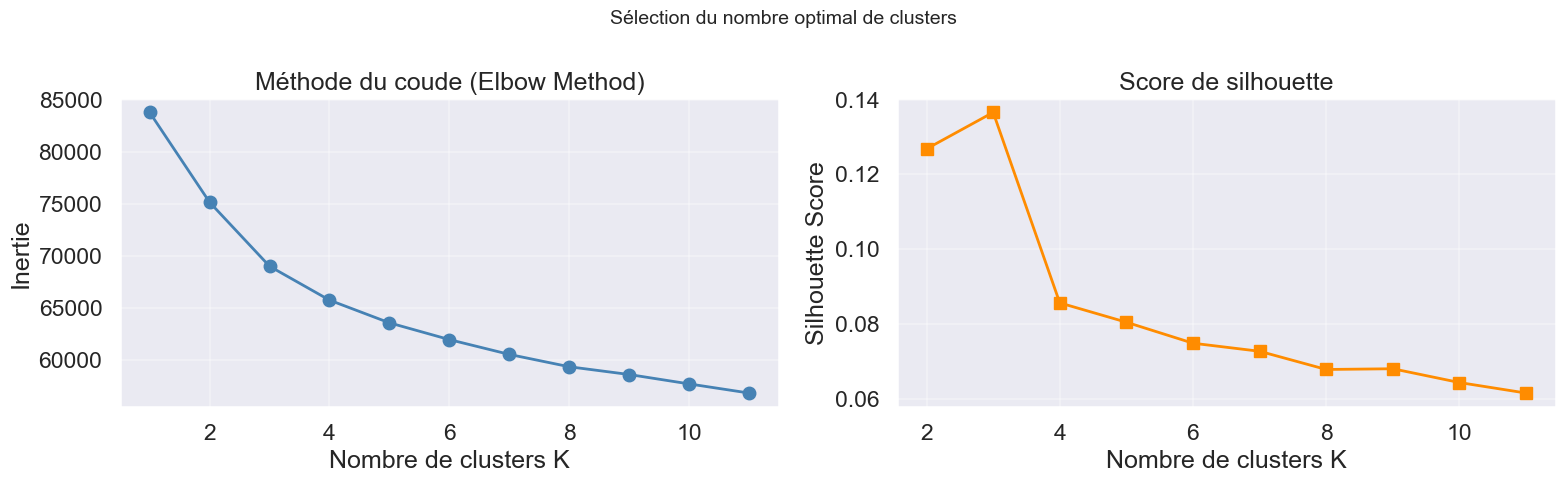

K optimal selon le score de silhouette : 3

Profil moyen par cluster :


Cluster,0,1,2
Age,35.68,42.52,35.14
DistanceFromHome,9.79,9.66,8.88
Education,2.81,2.92,2.94
JobLevel,2.07,1.88,2.13
MonthlyIncome,66468.69,67660.38,63716.44
NumCompaniesWorked,2.82,2.60,2.69
PercentSalaryHike,21.86,14.04,14.09
StockOptionLevel,0.71,0.78,0.82
TotalWorkingYears,10.33,19.27,8.53
TrainingTimesLastYear,2.69,2.78,2.83


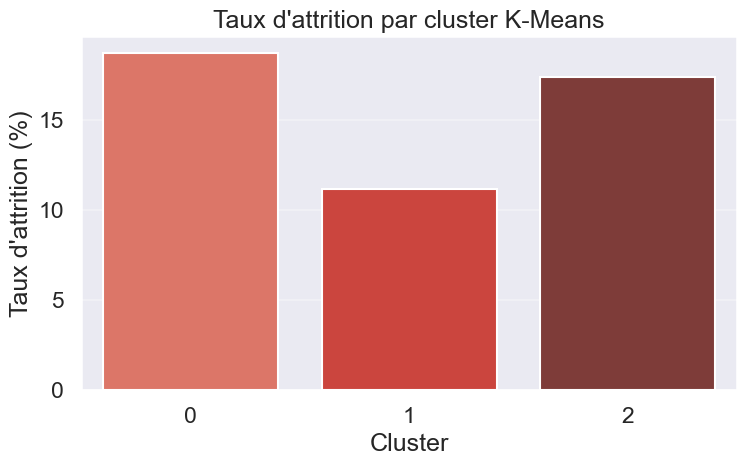


Répartition des employés par cluster :
Cluster
0     642
1    1020
2    2748
Name: count, dtype: int64


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# On travaille sur les données standardisées
X = df_standardized.values

# 1. Méthode du coude + Score de silhouette 
inertias        = []
silhouette_scores = []
K_range = range(1, 12) 
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X, km.labels_))
    else:
        silhouette_scores.append(None) 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Méthode du coude (Elbow Method)')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sélection du nombre optimal de clusters', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Entraînement final avec le K optimal 
K_OPTIMAL = max(zip(K_range, silhouette_scores), key=lambda x: x[1] if x[1] is not None else -1)[0]
print(f"K optimal selon le score de silhouette : {K_OPTIMAL}")

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X)

employee_data['Cluster'] = kmeans_final.labels_

# 3. Profil moyen de chaque cluster
cluster_profile = employee_data.groupby('Cluster')[cluster_features].mean()
print("\nProfil moyen par cluster :")
display(cluster_profile.T)

# 4. Taux d'attrition par cluster 
attrition_by_cluster = employee_data.groupby('Cluster')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
attrition_by_cluster.columns = ['Cluster', 'Attrition_Rate (%)']

plt.figure(figsize=(8, 5))
sns.barplot(data=attrition_by_cluster, x='Cluster', y='Attrition_Rate (%)',
            palette='Reds_d')
plt.title("Taux d'attrition par cluster K-Means")
plt.ylabel("Taux d'attrition (%)")
plt.xlabel("Cluster")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Taille des clusters
print("\nRépartition des employés par cluster :")
print(employee_data['Cluster'].value_counts().sort_index())